# Lesson 3: Stake effects and presentation order — de Hollander et al. (2024, bioRxiv)

## Background

De Hollander et al. (2024, *Nature Human Behaviour*) tested whether perceptual noise
during the encoding of numerical magnitudes explains risk aversion and its interaction
with presentation order.  The key design feature: the **order** in which the safe and
risky options are presented is randomised across trials, allowing the model to disentangle
$\nu_1$ (noise on the first-presented option) from $\nu_2$ (noise on the second-presented
option).

This produces a distinctive **presentation-order × stake-size interaction**: when the
safe option comes first, high safe stakes are compressed downward more strongly by the
prior → safe looks less attractive → the observer becomes more risk-seeking for high
stakes.  When the risky option comes first, the same mechanism operates on the risky
stakes → risk aversion for high stakes.

Standard models (EU, KLW with a shared noise) **cannot** capture this asymmetry.

### Models compared

| Model | Class | Key parameters |
|-------|-------|----------------|
| Expected Utility (EU) | `ExpectedUtilityRiskModel` | `alpha`, `sigma` |
| KLW | `RiskModel(prior_estimate='klw', fit_seperate_evidence_sd=False)` | `evidence_sd`, `prior_sd` (shared) |
| PMCM | `RiskModel(prior_estimate='full', fit_seperate_evidence_sd=True)` | `n1_evidence_sd`, `n2_evidence_sd`, `risky/safe_prior_mu/sd` |

We fit all three on both the **dot-cloud** (fMRI sessions 3T+7T) and the **symbolic**
(Arabic numerals) datasets, then compare posterior predictives against the interaction
pattern.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from bauer.utils.data import load_dehollander2024
from bauer.models import ExpectedUtilityRiskModel, RiskModel

# Load both fMRI sessions and combine
df_dot = load_dehollander2024(task='dotcloud', sessions=['3t2', '7t2'])
df_sym = load_dehollander2024(task='symbolic')

print(f"Dot clouds  — subjects: {df_dot.index.get_level_values('subject').nunique()}, "
      f"trials: {len(df_dot)}")
print(f"Symbolic    — subjects: {df_sym.index.get_level_values('subject').nunique()}, "
      f"trials: {len(df_sym)}")
df_dot.head()

Dot clouds  — subjects: 30, trials: 11445
Symbolic    — subjects: 58, trials: 14722


n1    n2    p1   p2  choice  risky_first
subject session run trial_nr                                            
02      3t2     1   1          5.0   5.0  0.55  1.0    True         True
                    2          7.0   7.0  0.55  1.0    True         True
                    3         37.0  20.0  0.55  1.0    True         True
                    4         47.0  20.0  0.55  1.0   False         True
                    5         18.0  10.0  0.55  1.0    True         True

In [2]:
def prep_df(df):
    """Add log_ratio, chose_risky, n_safe, order flag, and binned columns.
    Returns (df, stake_labels) where stake_labels lists the three stake-bin names
    with concrete magnitude ranges, e.g. ['Low (5–12)', 'Mid (12–24)', 'High (24–48)'].
    """
    df = df.reset_index()
    risky_first = df['p1'] == 0.55
    df['log_ratio']   = np.log(
        np.where(risky_first, df['n1'], df['n2']) /
        np.where(risky_first, df['n2'], df['n1']))
    df['chose_risky'] = np.where(risky_first, ~df['choice'], df['choice'])
    n_safe            = np.where(risky_first, df['n2'], df['n1'])
    df['n_safe']      = n_safe
    df['risky_first'] = risky_first
    df['order']       = np.where(risky_first, 'Risky first', 'Safe first')
    df['log_ratio_bin'] = (pd.cut(df['log_ratio'], bins=10)
                             .map(lambda x: x.mid).astype(float))
    _, bins = pd.qcut(n_safe, q=3, retbins=True, duplicates='drop')
    stake_labels = [
        f'Low ({bins[0]:.0f}–{bins[1]:.0f})',
        f'Mid ({bins[1]:.0f}–{bins[2]:.0f})',
        f'High ({bins[2]:.0f}–{bins[3]:.0f})',
    ]
    df['n_safe_bin'] = pd.qcut(n_safe, q=3, labels=stake_labels, duplicates='drop')
    return df, stake_labels

df_dot_p, dot_stake_labels = prep_df(df_dot)
df_sym_p, sym_stake_labels = prep_df(df_sym)

# Sequential (light→dark) palette for stake sizes — hue in existing order×stake plots
def make_stake_pal(labels):
    cols = sns.color_palette('YlOrRd', len(labels))   # yellow → orange → red
    return dict(zip(labels, cols))

dot_stake_pal = make_stake_pal(dot_stake_labels)
sym_stake_pal = make_stake_pal(sym_stake_labels)

# Order palette: standard seaborn blue/orange
order_pal = {'Safe first': sns.color_palette()[0],    # blue
             'Risky first': sns.color_palette()[1]}   # orange

## Presentation-order x stake-size interaction

Each panel shows P(chose risky) as a function of the log risky/safe magnitude ratio,
split by safe-option stake tertile.  The left column shows trials where the risky option
came first; the right column shows trials where the safe option came first.

The dashed vertical line marks the risk-neutral indifference point log(1/0.55).

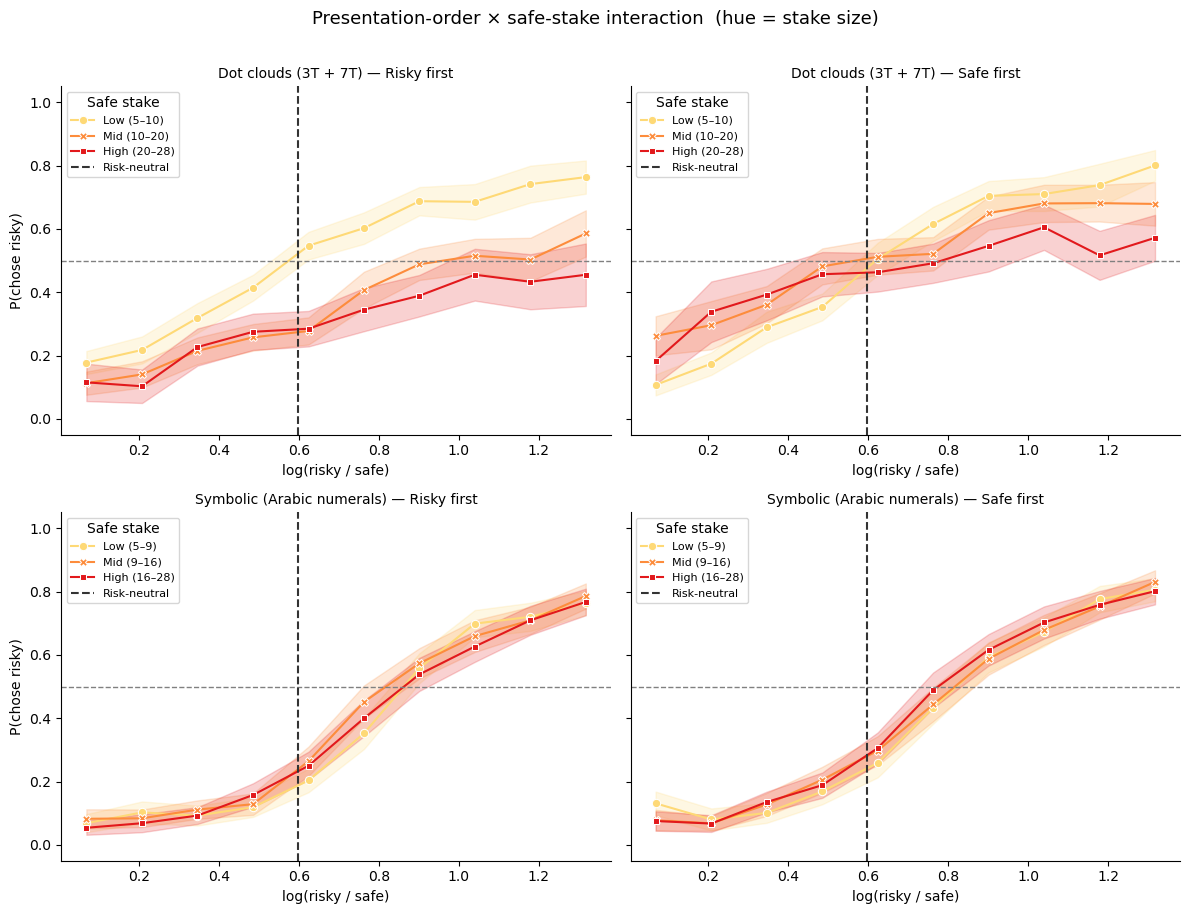

In [3]:
def plot_interaction(df_p, axes_row, task_label, stake_labels, stake_pal):
    """Columns = order condition, hue = safe-stake tertile."""
    for ax, order_val in zip(axes_row, ['Risky first', 'Safe first']):
        sub  = df_p[df_p['order'] == order_val]
        subj = (sub.groupby(['subject', 'log_ratio_bin', 'n_safe_bin'])['chose_risky']
                   .mean().reset_index())
        subj = subj[subj.groupby(['log_ratio_bin', 'n_safe_bin'])
                        ['subject'].transform('count') >= 3]
        sns.lineplot(data=subj, x='log_ratio_bin', y='chose_risky',
                     hue='n_safe_bin', style='n_safe_bin',
                     hue_order=stake_labels, style_order=stake_labels,
                     palette=stake_pal, markers=True, dashes=False,
                     errorbar='se', ax=ax)
        ax.axhline(.5,            ls='--', c='gray', lw=1)
        ax.axvline(np.log(1/.55), ls='--', c='#333333', lw=1.5, label='Risk-neutral')
        ax.set_ylim(-.05, 1.05)
        ax.set_xlabel('log(risky / safe)')
        ax.set_ylabel('P(chose risky)')
        ax.set_title(f'{task_label} — {order_val}', fontsize=10)
        ax.legend(title='Safe stake', fontsize=8)
        sns.despine(ax=ax)


def plot_interaction_by_stake(df_p, axes_row, task_label, stake_labels):
    """Columns = safe-stake tertile, hue = order condition (orange/blue)."""
    for ax, sbin in zip(axes_row, stake_labels):
        sub  = df_p[df_p['n_safe_bin'] == sbin]
        subj = (sub.groupby(['subject', 'log_ratio_bin', 'order'])['chose_risky']
                   .mean().reset_index())
        subj = subj[subj.groupby(['log_ratio_bin', 'order'])
                        ['subject'].transform('count') >= 3]
        sns.lineplot(data=subj, x='log_ratio_bin', y='chose_risky',
                     hue='order', style='order',
                     hue_order=['Risky first', 'Safe first'],
                     palette=order_pal, markers=True, dashes=False,
                     errorbar='se', ax=ax)
        ax.axhline(.5,            ls='--', c='gray', lw=1)
        ax.axvline(np.log(1/.55), ls='--', c='#333333', lw=1.5)
        ax.set_ylim(-.05, 1.05)
        ax.set_xlabel('log(risky / safe)')
        ax.set_ylabel('P(chose risky)')
        ax.set_title(f'{task_label} — {sbin}', fontsize=10)
        ax.legend(title='Order', fontsize=8)
        sns.despine(ax=ax)


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
plot_interaction(df_dot_p, axes[0], 'Dot clouds (3T + 7T)', dot_stake_labels, dot_stake_pal)
plot_interaction(df_sym_p, axes[1], 'Symbolic (Arabic numerals)', sym_stake_labels, sym_stake_pal)
plt.suptitle('Presentation-order × safe-stake interaction  (hue = stake size)', fontsize=13, y=1.01)
plt.tight_layout()

### Alternative view: stake size × order (hue = order)

The same data shown with columns = stake tertile and hue = presentation order.
Orange = risky option presented first; blue = safe option presented first.

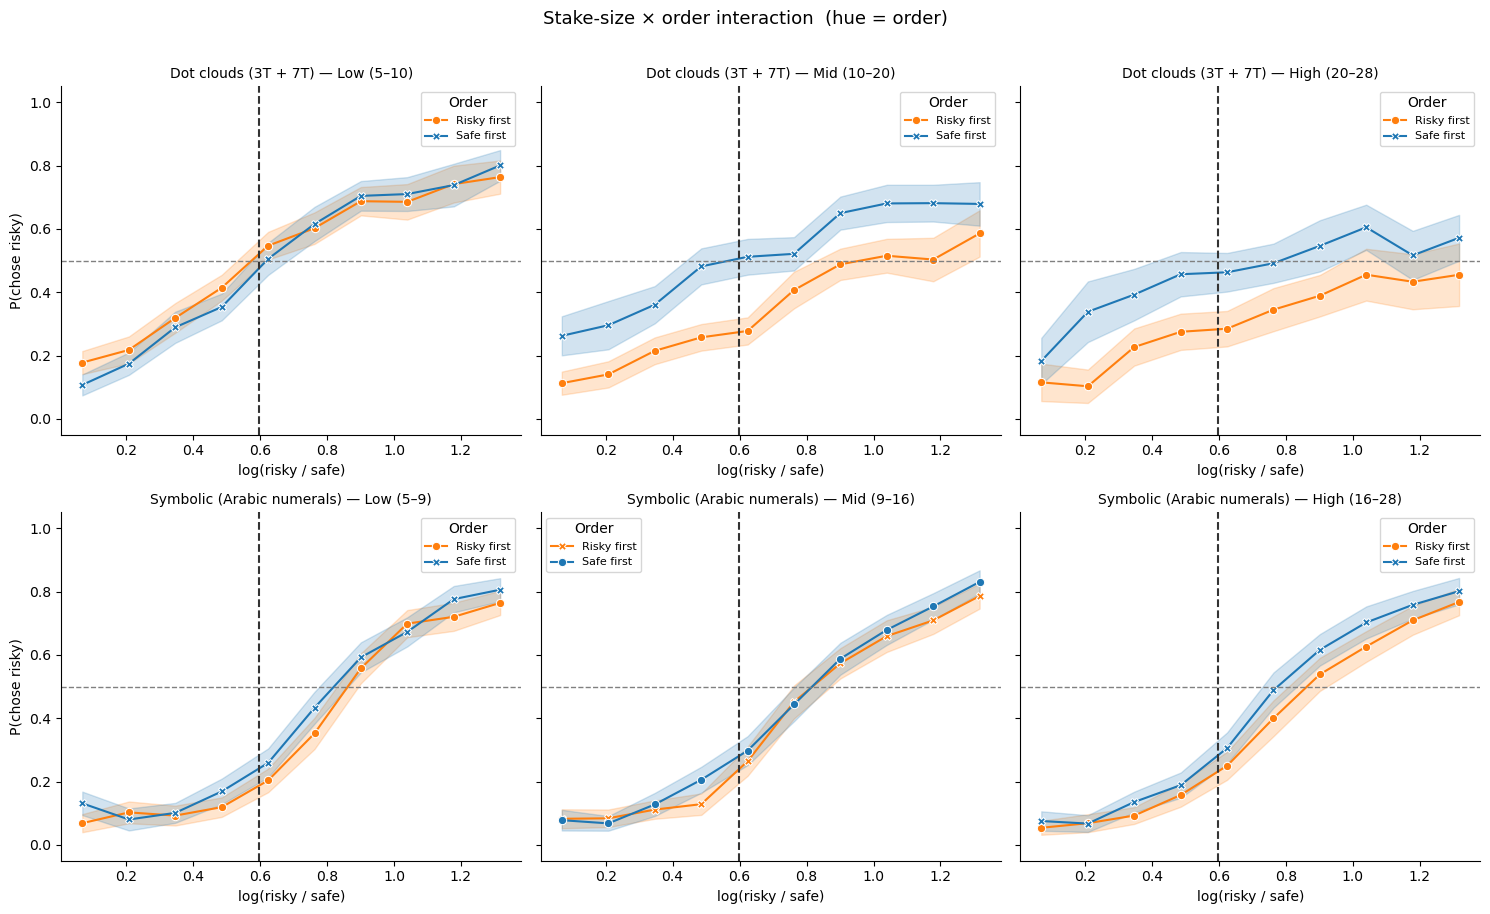

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
plot_interaction_by_stake(df_dot_p, axes[0], 'Dot clouds (3T + 7T)', dot_stake_labels)
plot_interaction_by_stake(df_sym_p, axes[1], 'Symbolic (Arabic numerals)', sym_stake_labels)
plt.suptitle('Stake-size × order interaction  (hue = order)', fontsize=13, y=1.01)
plt.tight_layout()

## Fit three models — dot-cloud data

Hierarchical MCMC, 100 draws / 100 tune / 2 chains.  We store log-likelihoods
(`log_likelihood=True`) for ELPD model comparison later.

In [5]:
# ── 1. Expected Utility ──────────────────────────────────────────────────────
model_eu = ExpectedUtilityRiskModel(paradigm=df_dot)
model_eu.build_estimation_model(data=df_dot, hierarchical=True, save_p_choice=True)
idata_eu = model_eu.sample(draws=100, tune=100, chains=2, progressbar=False,
                            idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [alpha_mu_untransformed, alpha_sd, alpha_offset, sigma_mu_untransformed, sigma_sd, sigma_offset]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 65 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [6]:
# ── 2. KLW (shared noise, shared prior) ─────────────────────────────────────
model_klw = RiskModel(paradigm=df_dot, prior_estimate='klw',
                      fit_seperate_evidence_sd=False)
model_klw.build_estimation_model(data=df_dot, hierarchical=True, save_p_choice=True)
idata_klw = model_klw.sample(draws=100, tune=100, chains=2, progressbar=False,
                              idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [evidence_sd_mu_untransformed, evidence_sd_sd, evidence_sd_offset, prior_sd_mu_untransformed, prior_sd_sd, prior_sd_offset]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 55 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [7]:
# ── 3. PMCM (separate noise + separate priors) ────────────────────
model_full = RiskModel(paradigm=df_dot, prior_estimate='full',
                       fit_seperate_evidence_sd=True)
model_full.build_estimation_model(data=df_dot, hierarchical=True, save_p_choice=True)
idata_full = model_full.sample(draws=100, tune=100, chains=2, progressbar=False,
                                idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_prior_mu_mu, safe_prior_mu_sd, safe_prior_mu_offset, safe_prior_sd_mu_untransformed, safe_prior_sd_sd, safe_prior_sd_offset]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 80 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Posterior predictives — dot-cloud data

Dots = observed group average; line + shading = model mean and 95 % posterior interval.

Sampling: [ll_bernoulli]


Output()

Sampling: [ll_bernoulli]


Output()

Sampling: [ll_bernoulli]


Output()

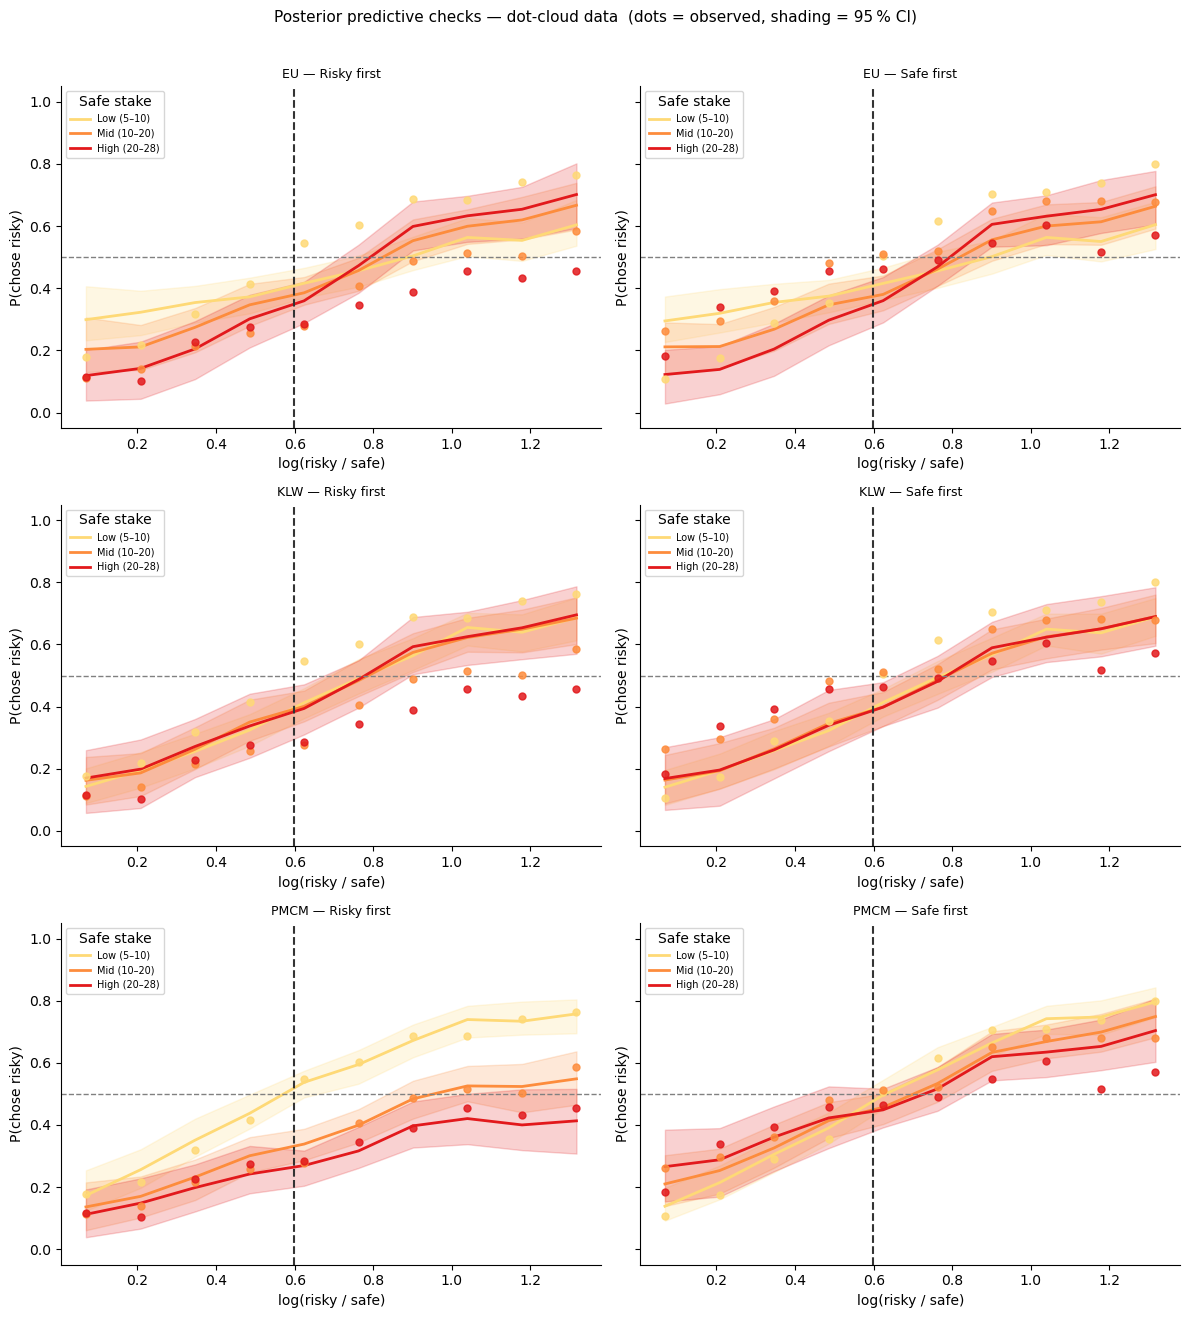

In [8]:
from bauer.utils import summarize_ppc_group

def add_model_ppc(df_orig, df_prepped, model, idata, model_name, stake_labels):
    """Condition-level PPC via summarize_ppc_group (two-step subject averaging)."""
    ppc_df  = model.ppc(df_orig, idata, var_names=['ll_bernoulli'])
    ppc_ll  = ppc_df.xs('ll_bernoulli', level='variable')
    sample_cols = ppc_ll.columns.tolist()

    ppc_flat = ppc_ll.reset_index()
    risky_first = (ppc_flat['p1'] == 0.55)
    ppc_flat[sample_cols] = np.where(
        risky_first.values[:, None],
        1 - ppc_flat[sample_cols].values,
        ppc_flat[sample_cols].values
    )
    ppc_flat['order'] = np.where(risky_first, 'Risky first', 'Safe first')
    log_ratio = np.log(
        np.where(risky_first, ppc_flat['n1'], ppc_flat['n2']) /
        np.where(risky_first, ppc_flat['n2'], ppc_flat['n1']))
    ppc_flat['log_ratio_bin'] = (pd.cut(pd.Series(log_ratio), bins=10)
                                   .map(lambda x: x.mid).astype(float).values)
    n_safe = np.where(risky_first, ppc_flat['n2'], ppc_flat['n1'])
    ppc_flat['n_safe_bin'] = pd.qcut(n_safe, q=3, labels=stake_labels, duplicates='drop')

    result = summarize_ppc_group(
        ppc_flat,
        condition_cols=['order', 'n_safe_bin', 'log_ratio_bin']
    )
    return result.rename(columns={'p_predicted': 'p_mean',
                                   'hdi025': 'p_lo', 'hdi975': 'p_hi'}).reset_index()


def plot_ppc_interaction(df_pred, df_obs, model_name, axes_row, stake_labels, stake_pal):
    """Columns = order; hue = stake tertile (sequential palette)."""
    for ax, order_val in zip(axes_row, ['Risky first', 'Safe first']):
        pred = df_pred[df_pred['order'] == order_val]
        obs  = df_obs[df_obs['order']   == order_val]
        for sbin in stake_labels:
            p = pred[pred['n_safe_bin'] == sbin]
            o = obs[obs['n_safe_bin']   == sbin]
            if len(o) == 0:
                continue
            c = stake_pal[sbin]
            ax.fill_between(p['log_ratio_bin'], p['p_lo'], p['p_hi'], color=c, alpha=.20)
            ax.plot(p['log_ratio_bin'], p['p_mean'], color=c, lw=2, label=sbin)
            ax.scatter(o['log_ratio_bin'], o['chose_risky'],
                       color=c, s=25, zorder=5, alpha=.85)
        ax.axhline(.5,            ls='--', c='gray', lw=1)
        ax.axvline(np.log(1/.55), ls='--', c='#333333', lw=1.5)
        ax.set_ylim(-.05, 1.05)
        ax.set_title(f'{model_name} — {order_val}', fontsize=9)
        ax.set_xlabel('log(risky / safe)'); ax.set_ylabel('P(chose risky)')
        ax.legend(title='Safe stake', fontsize=7, loc='upper left')
        sns.despine(ax=ax)


def plot_ppc_by_stake(df_pred, df_obs, model_name, axes_row, stake_labels):
    """Columns = stake tertile; hue = order (orange/blue)."""
    for ax, sbin in zip(axes_row, stake_labels):
        pred = df_pred[df_pred['n_safe_bin'] == sbin]
        obs  = df_obs[df_obs['n_safe_bin']   == sbin]
        for order_val in ['Risky first', 'Safe first']:
            p = pred[pred['order'] == order_val]
            o = obs[obs['order']   == order_val]
            if len(o) == 0:
                continue
            c = order_pal[order_val]
            ax.fill_between(p['log_ratio_bin'], p['p_lo'], p['p_hi'], color=c, alpha=.20)
            ax.plot(p['log_ratio_bin'], p['p_mean'], color=c, lw=2, label=order_val)
            ax.scatter(o['log_ratio_bin'], o['chose_risky'],
                       color=c, s=25, zorder=5, alpha=.85)
        ax.axhline(.5,            ls='--', c='gray', lw=1)
        ax.axvline(np.log(1/.55), ls='--', c='#333333', lw=1.5)
        ax.set_ylim(-.05, 1.05)
        ax.set_title(f'{model_name} — {sbin}', fontsize=9)
        ax.set_xlabel('log(risky / safe)'); ax.set_ylabel('P(chose risky)')
        ax.legend(title='Order', fontsize=7, loc='upper left')
        sns.despine(ax=ax)


# Observed: two-step average matching the PPC computation
obs_dot = (df_dot_p
           .groupby(['subject', 'order', 'n_safe_bin', 'log_ratio_bin'])['chose_risky']
           .mean()
           .groupby(['order', 'n_safe_bin', 'log_ratio_bin']).mean()
           .reset_index())

fig, axes = plt.subplots(3, 2, figsize=(12, 13), sharey=True)
ppc_dot = {}
for (mdl, idat, name), row in zip(
        [(model_eu,   idata_eu,   'EU'),
         (model_klw,  idata_klw,  'KLW'),
         (model_full, idata_full, 'PMCM')],
        axes):
    ppc_dot[name] = add_model_ppc(df_dot, df_dot_p, mdl, idat, name, dot_stake_labels)
    plot_ppc_interaction(ppc_dot[name], obs_dot, name, row, dot_stake_labels, dot_stake_pal)

plt.suptitle('Posterior predictive checks — dot-cloud data  (dots = observed, shading = 95 % CI)',
             fontsize=11, y=1.01)
plt.tight_layout()

### Alternative PPC view: columns = stake size, hue = order

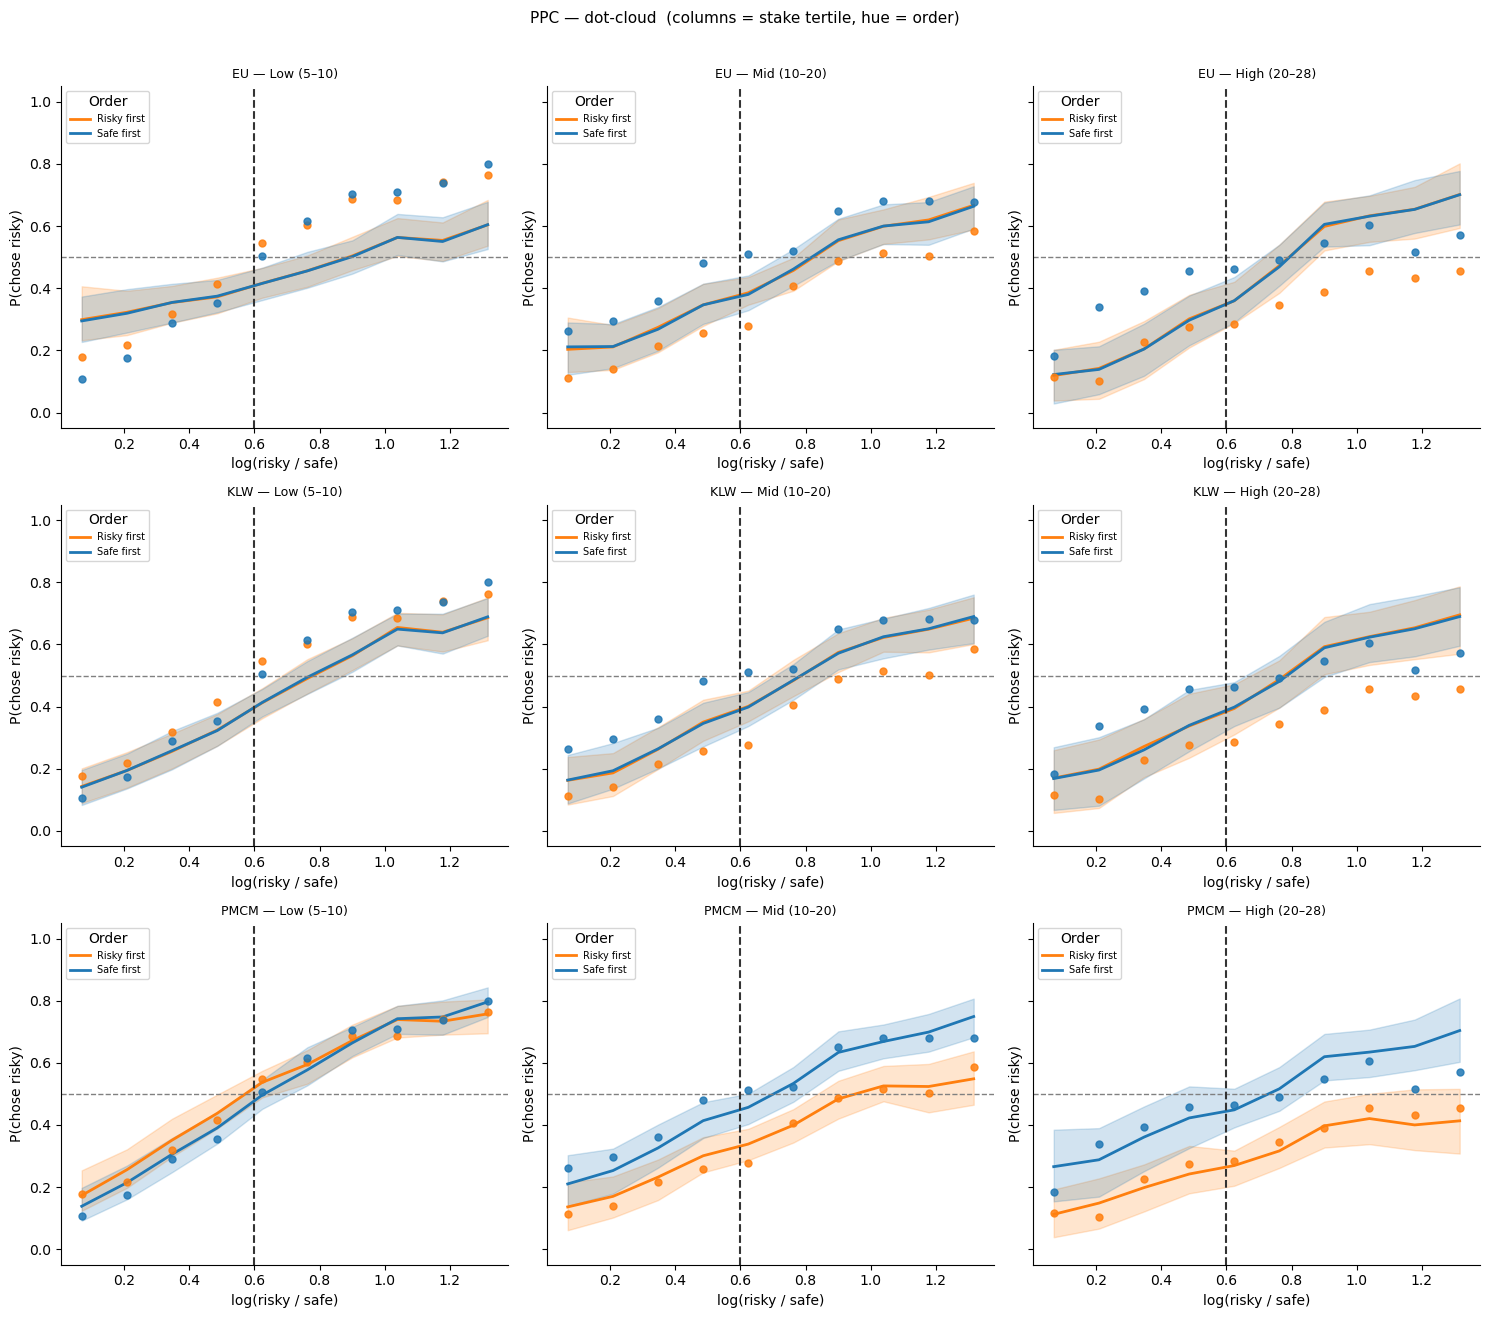

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharey=True)
for (name, df_pred), row in zip(ppc_dot.items(), axes):
    plot_ppc_by_stake(df_pred, obs_dot, name, row, dot_stake_labels)

plt.suptitle('PPC — dot-cloud  (columns = stake tertile, hue = order)',
             fontsize=11, y=1.01)
plt.tight_layout()

## Fit three models — symbolic data

In [10]:
# ── 1. EU ────────────────────────────────────────────────────────────────────
model_eu_sym = ExpectedUtilityRiskModel(paradigm=df_sym)
model_eu_sym.build_estimation_model(data=df_sym, hierarchical=True, save_p_choice=True)
idata_eu_sym = model_eu_sym.sample(draws=100, tune=100, chains=2, progressbar=False,
                                        idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [alpha_mu_untransformed, alpha_sd, alpha_offset, sigma_mu_untransformed, sigma_sd, sigma_offset]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 108 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [11]:
# ── 2. KLW ───────────────────────────────────────────────────────────────────
model_klw_sym = RiskModel(paradigm=df_sym, prior_estimate='klw',
                           fit_seperate_evidence_sd=False)
model_klw_sym.build_estimation_model(data=df_sym, hierarchical=True, save_p_choice=True)
idata_klw_sym = model_klw_sym.sample(draws=100, tune=100, chains=2, progressbar=False,
                                          idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [evidence_sd_mu_untransformed, evidence_sd_sd, evidence_sd_offset, prior_sd_mu_untransformed, prior_sd_sd, prior_sd_offset]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 115 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [12]:
# ── 3. PMCM ────────────────────────────────────────────────────────
model_full_sym = RiskModel(paradigm=df_sym, prior_estimate='full',
                            fit_seperate_evidence_sd=True)
model_full_sym.build_estimation_model(data=df_sym, hierarchical=True, save_p_choice=True)
idata_full_sym = model_full_sym.sample(draws=100, tune=100, chains=2, progressbar=False,
                                            idata_kwargs={'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_prior_mu_mu, safe_prior_mu_sd, safe_prior_mu_offset, safe_prior_sd_mu_untransformed, safe_prior_sd_sd, safe_prior_sd_offset]


Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 132 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Posterior predictives — symbolic data

Sampling: [ll_bernoulli]


Output()

Sampling: [ll_bernoulli]


Output()

Sampling: [ll_bernoulli]


Output()

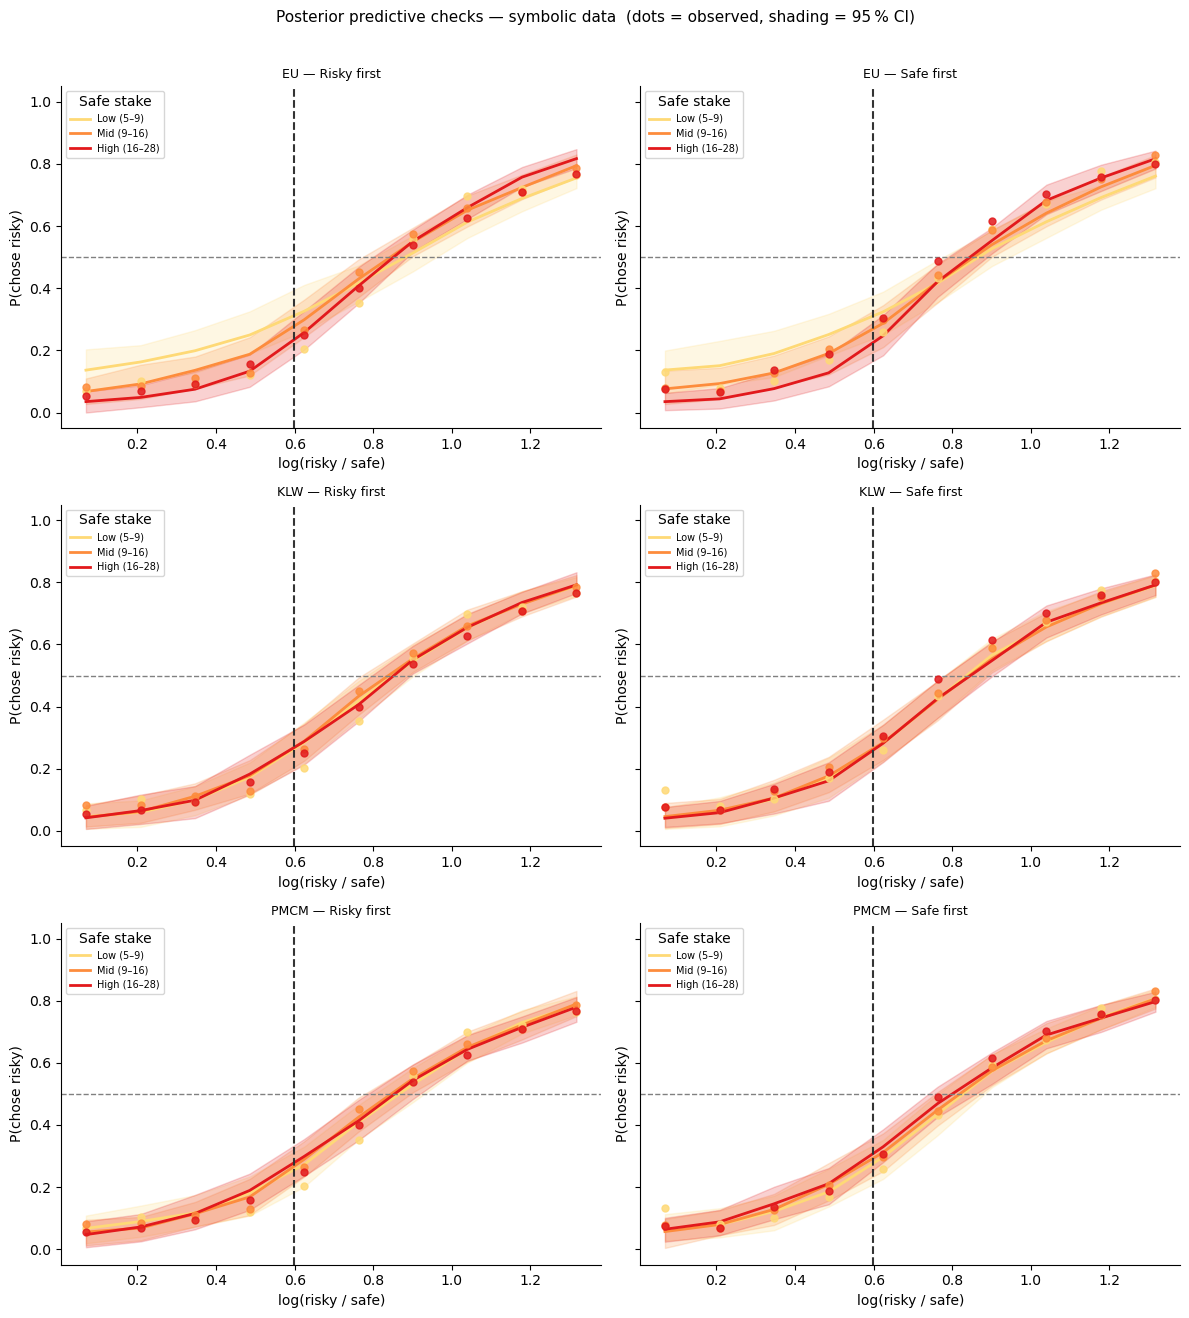

In [13]:
obs_sym = (df_sym_p
           .groupby(['subject', 'order', 'n_safe_bin', 'log_ratio_bin'])['chose_risky']
           .mean()
           .groupby(['order', 'n_safe_bin', 'log_ratio_bin']).mean()
           .reset_index())

fig, axes = plt.subplots(3, 2, figsize=(12, 13), sharey=True)
ppc_sym = {}
for (mdl, idat, name), row in zip(
        [(model_eu_sym,   idata_eu_sym,   'EU'),
         (model_klw_sym,  idata_klw_sym,  'KLW'),
         (model_full_sym, idata_full_sym, 'PMCM')],
        axes):
    ppc_sym[name] = add_model_ppc(df_sym, df_sym_p, mdl, idat, name, sym_stake_labels)
    plot_ppc_interaction(ppc_sym[name], obs_sym, name, row, sym_stake_labels, sym_stake_pal)

plt.suptitle('Posterior predictive checks — symbolic data  (dots = observed, shading = 95 % CI)',
             fontsize=11, y=1.01)
plt.tight_layout()

### Alternative PPC view: columns = stake size, hue = order (symbolic)

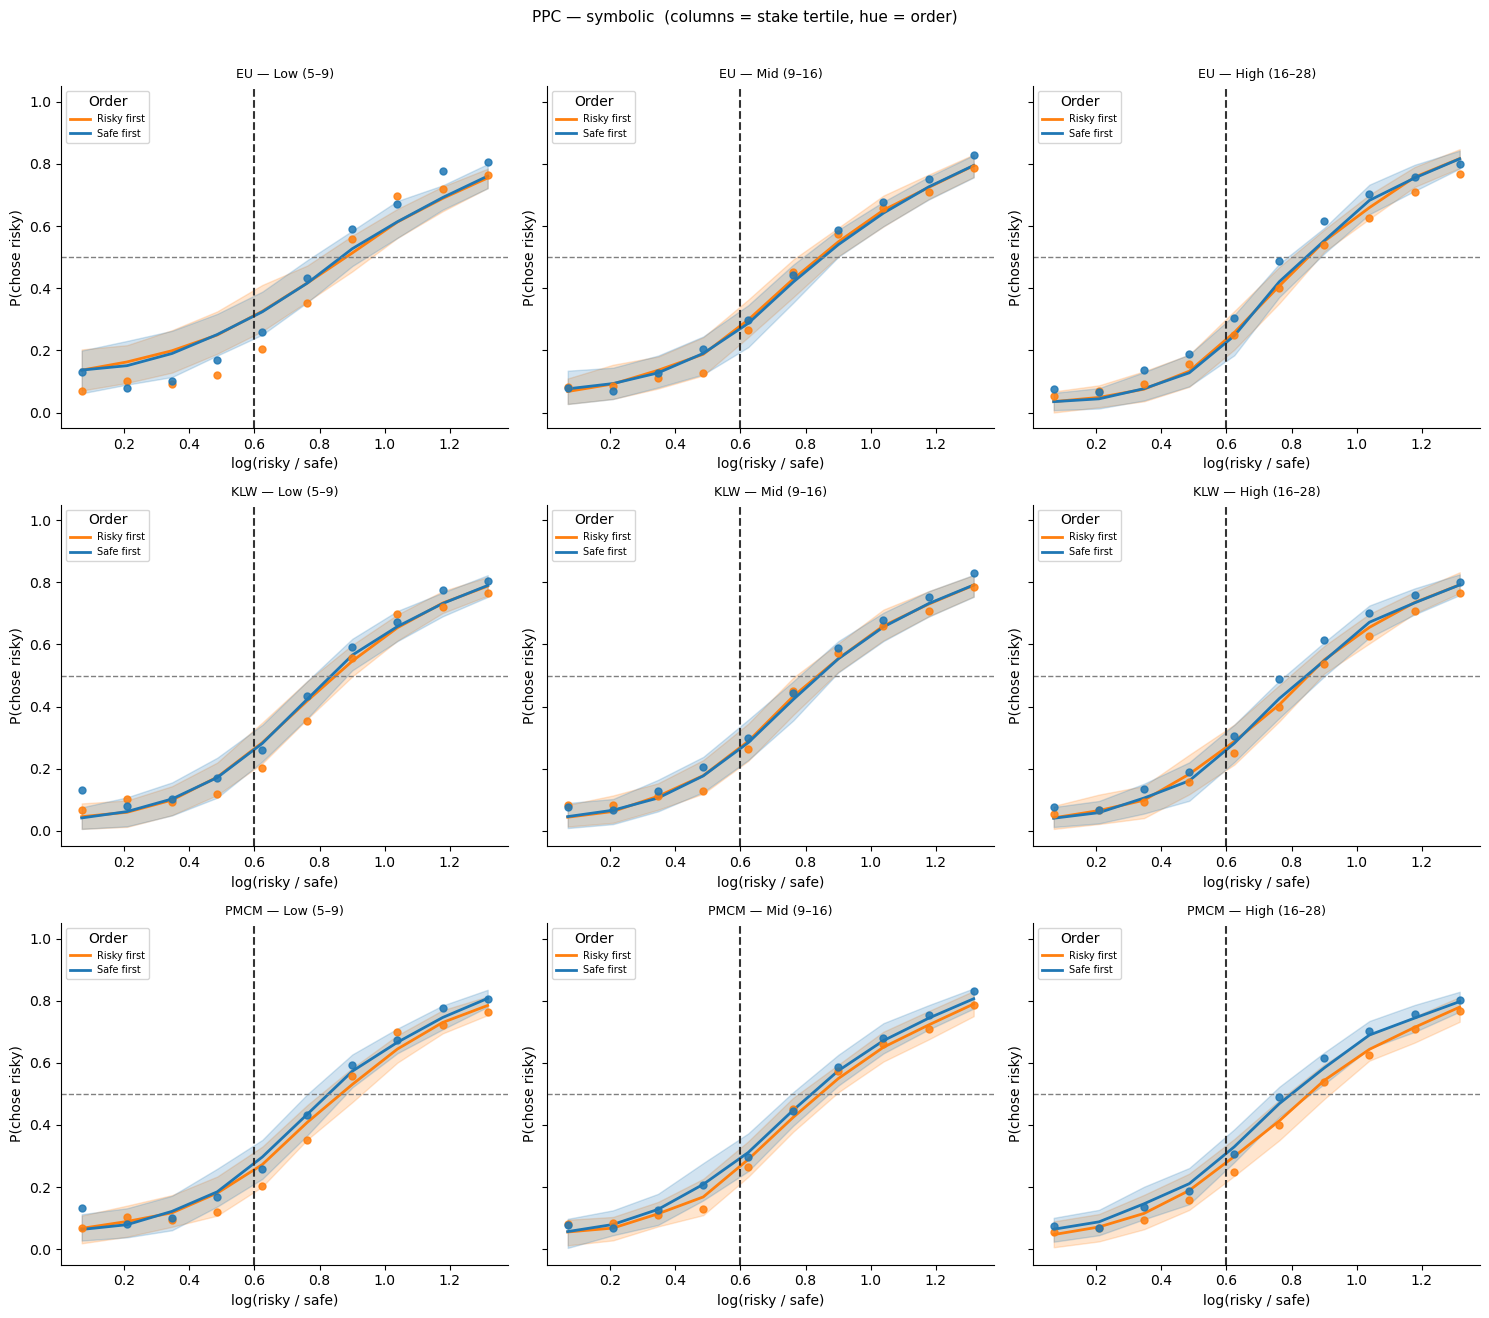

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharey=True)
for (name, df_pred), row in zip(ppc_sym.items(), axes):
    plot_ppc_by_stake(df_pred, obs_sym, name, row, sym_stake_labels)

plt.suptitle('PPC — symbolic  (columns = stake tertile, hue = order)',
             fontsize=11, y=1.01)
plt.tight_layout()

## Parameter interpretation: $\nu_1$ vs $\nu_2$

bauer's `get_subject_posterior_df` creates a tidy summary DataFrame, and
`plot_subjectwise_pointplot` maps it onto a FacetGrid — one panel per parameter per task.

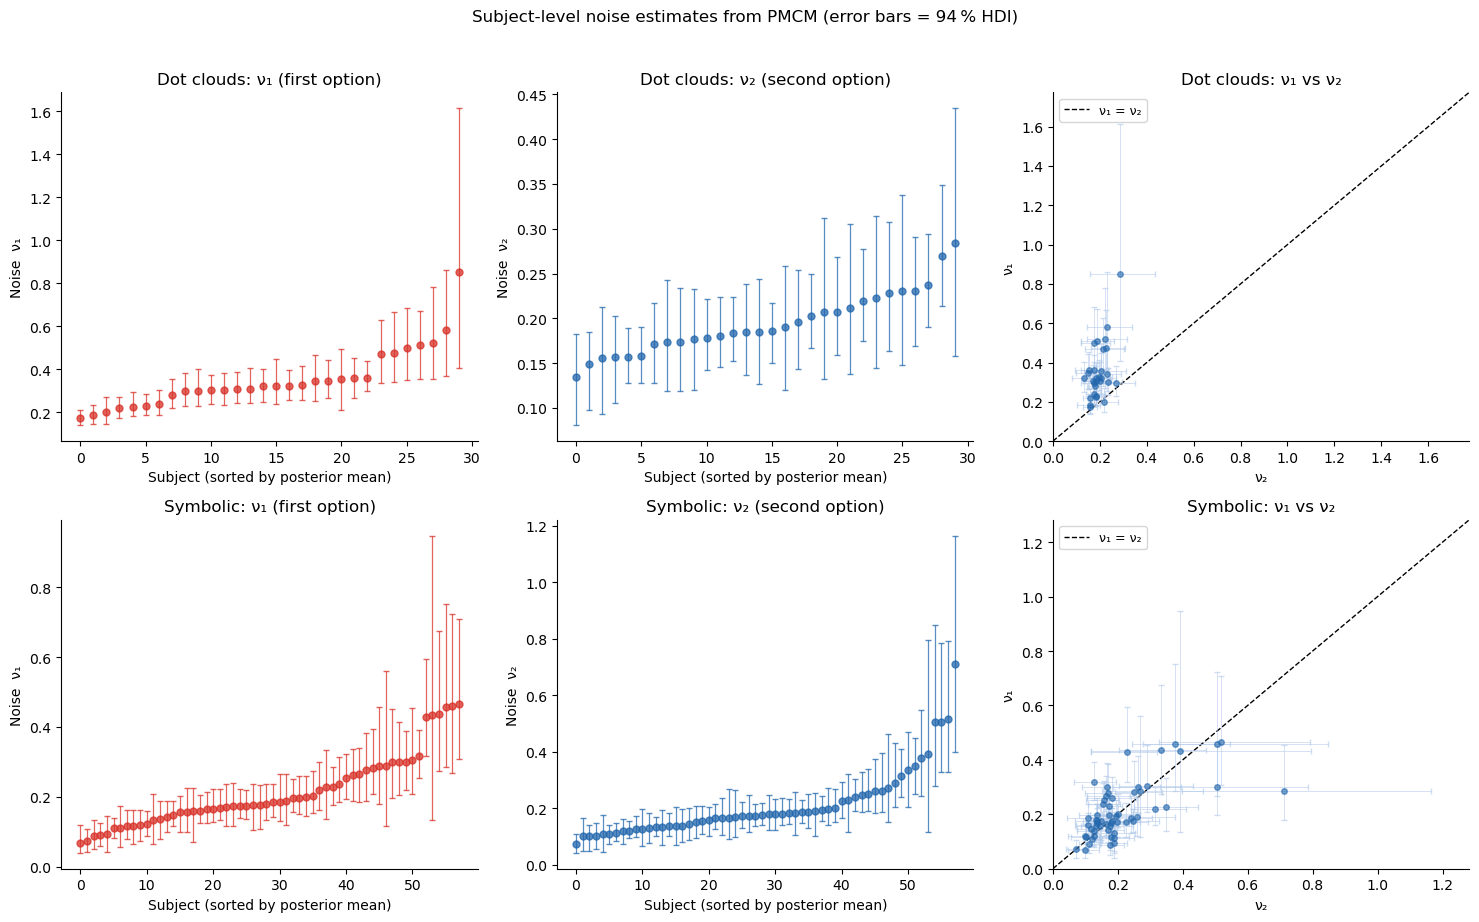

In [15]:
from bauer.utils import get_subject_posterior_df, plot_subjectwise_pointplot

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row_axes, (idat, task_label) in zip(axes,
        [(idata_full,     'Dot clouds'),
         (idata_full_sym, 'Symbolic')]):

    df_post = get_subject_posterior_df(idat, ['n1_evidence_sd', 'n2_evidence_sd'])

    # Left: ν₁ sorted pointplot (direct call with ax=)
    d1 = df_post[df_post['parameter'] == 'n1_evidence_sd'].reset_index(drop=True)
    plot_subjectwise_pointplot(d1, color='#d73027', ax=row_axes[0])
    row_axes[0].set_title(f'{task_label}: ν₁ (first option)')
    row_axes[0].set_ylabel('Noise  ν₁')

    # Middle: ν₂ sorted pointplot
    d2 = df_post[df_post['parameter'] == 'n2_evidence_sd'].reset_index(drop=True)
    plot_subjectwise_pointplot(d2, color='#2166ac', ax=row_axes[1])
    row_axes[1].set_title(f'{task_label}: ν₂ (second option)')
    row_axes[1].set_ylabel('Noise  ν₂')

    # Right: ν₁ vs ν₂ scatter
    n_subj = idat.posterior['n1_evidence_sd'].shape[-1]
    s1 = idat.posterior['n1_evidence_sd'].values.reshape(-1, n_subj)
    s2 = idat.posterior['n2_evidence_sd'].values.reshape(-1, n_subj)
    nu1_mean, nu2_mean = s1.mean(0), s2.mean(0)
    nu1_lo, nu1_hi = np.percentile(s1, [3, 97], axis=0)
    nu2_lo, nu2_hi = np.percentile(s2, [3, 97], axis=0)
    lim = max(nu1_hi.max(), nu2_hi.max()) * 1.1
    row_axes[2].errorbar(nu2_mean, nu1_mean,
                xerr=[nu2_mean - nu2_lo, nu2_hi - nu2_mean],
                yerr=[nu1_mean - nu1_lo, nu1_hi - nu1_mean],
                fmt='o', ms=4, alpha=.6, elinewidth=0.6, capsize=2,
                color='#2166ac', ecolor='#aec7e8', zorder=3)
    row_axes[2].plot([0, lim], [0, lim], 'k--', lw=1, label='ν₁ = ν₂')
    row_axes[2].set_xlim(0, lim); row_axes[2].set_ylim(0, lim)
    row_axes[2].set_xlabel('ν₂'); row_axes[2].set_ylabel('ν₁')
    row_axes[2].set_title(f'{task_label}: ν₁ vs ν₂')
    row_axes[2].legend(fontsize=9); sns.despine(ax=row_axes[2])

plt.suptitle('Subject-level noise estimates from PMCM (error bars = 94 % HDI)',
             fontsize=12, y=1.02)
plt.tight_layout()

## Individual differences in noise asymmetry

The group average $\nu_1 > \nu_2$ suggests a **memory effect**: the first-presented option
is noisier because it must be held in working memory.  But this is only part of the story.

In the **symbolic** task, the picture is more nuanced.  Not every participant shows a memory
effect — some appear to show an **attentional primacy** effect where they focus *more* on
the first option ($\nu_1 < \nu_2$).  The distribution of $\nu_1 - \nu_2$ across
participants reveals this heterogeneity.

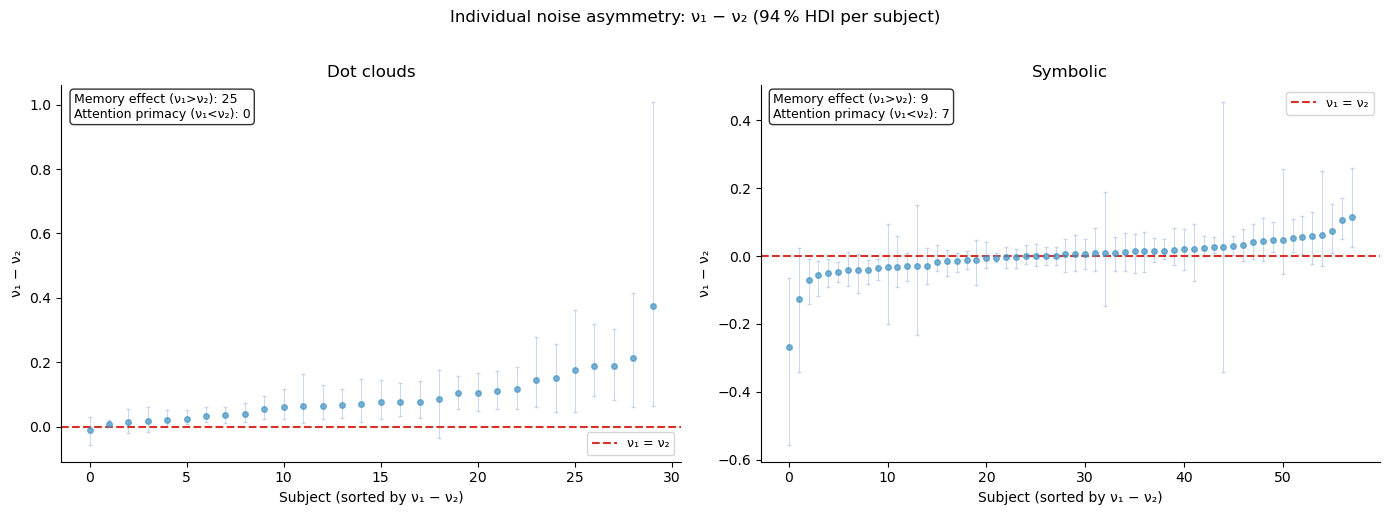

In [16]:
# ── ν₁ − ν₂ difference per subject ──────────────────────────────────────────
from bauer.utils.math import softplus_np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (idat, task_label) in zip(axes,
        [(idata_full, 'Dot clouds'), (idata_full_sym, 'Symbolic')]):
    n_subj = idat.posterior['n1_evidence_sd'].shape[-1]
    s1 = softplus_np(idat.posterior['n1_evidence_sd'].values.reshape(-1, n_subj))
    s2 = softplus_np(idat.posterior['n2_evidence_sd'].values.reshape(-1, n_subj))
    diff = s1 - s2   # positive = memory effect (ν₁ > ν₂)

    diff_mean = diff.mean(0)
    diff_lo   = np.percentile(diff, 3, 0)
    diff_hi   = np.percentile(diff, 97, 0)

    sort_idx = np.argsort(diff_mean)
    x = np.arange(n_subj)

    ax.errorbar(x, diff_mean[sort_idx],
                yerr=[diff_mean[sort_idx] - diff_lo[sort_idx],
                      diff_hi[sort_idx] - diff_mean[sort_idx]],
                fmt='o', ms=4, elinewidth=0.7, capsize=1.5, alpha=.7,
                color='#4393c3', ecolor='#aec7e8')
    ax.axhline(0, ls='--', c='#d73027', lw=1.5, label='ν₁ = ν₂')
    ax.set_xlabel('Subject (sorted by ν₁ − ν₂)')
    ax.set_ylabel('ν₁ − ν₂')
    ax.set_title(f'{task_label}')
    n_mem = (diff_lo[sort_idx] > 0).sum()
    n_att = (diff_hi[sort_idx] < 0).sum()
    ax.text(0.02, 0.98, f'Memory effect (ν₁>ν₂): {n_mem}\nAttention primacy (ν₁<ν₂): {n_att}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=.8))
    ax.legend(fontsize=9); sns.despine(ax=ax)

plt.suptitle('Individual noise asymmetry: ν₁ − ν₂ (94 % HDI per subject)',
             fontsize=12, y=1.02)
plt.tight_layout()

### Interpreting the heterogeneity

For **dot clouds**, most participants show $\nu_1 > \nu_2$ (memory effect) — consistent with
the sequential presentation degrading the first option in working memory.

For **symbolic (Arabic numeral)** stimuli, the pattern is more mixed:
- Some participants still show a memory effect ($\nu_1 > \nu_2$)
- Others show the opposite: $\nu_1 < \nu_2$ — as if they allocate more **attention** to the
  first-presented option and less to the second

This suggests that with symbolic stimuli (which are faster to encode than dot clouds), the
bottleneck shifts from working memory to **attentional allocation**, and different participants
adopt different strategies.

## Subject-level PPCs: do the models capture individual strategies?

Group-level PPCs can look fine while hiding poor fits for individual participants.
We pick three subjects — one with a strong memory effect ($\nu_1 \gg \nu_2$), one
balanced, and one with an attentional-primacy effect ($\nu_1 < \nu_2$) — and show
their individual posterior predictives under the three models.

In [17]:
# Identify 5 most extreme subjects in each direction (symbolic task)
from bauer.utils.math import softplus_np
n_subj_sym = idata_full_sym.posterior['n1_evidence_sd'].shape[-1]
s1_sym = softplus_np(idata_full_sym.posterior['n1_evidence_sd'].values.reshape(-1, n_subj_sym))
s2_sym = softplus_np(idata_full_sym.posterior['n2_evidence_sd'].values.reshape(-1, n_subj_sym))
diff_sym = (s1_sym - s2_sym).mean(0)
sym_subjects = idata_full_sym.posterior['n1_evidence_sd'].coords['subject'].values

rank = np.argsort(diff_sym)
top5_memory    = sym_subjects[rank[-5:]]   # highest ν₁ - ν₂
top5_attention = sym_subjects[rank[:5]]    # lowest ν₁ - ν₂
print(f"Memory-effect subjects:    {top5_memory}  (mean Δν = {diff_sym[rank[-5:]].mean():.3f})")
print(f"Attention-primacy subjects: {top5_attention}  (mean Δν = {diff_sym[rank[:5]].mean():.3f})")

Memory-effect subjects:    ['13' '58' '129' '52' '139']  (mean Δν = 0.084)
Attention-primacy subjects: ['93' '87' '127' '90' '106']  (mean Δν = -0.113)


Sampling: []


Output()

Sampling: []


Output()

Sampling: []


...

Output()

Sampling: []


Output()

Sampling: []


Output()

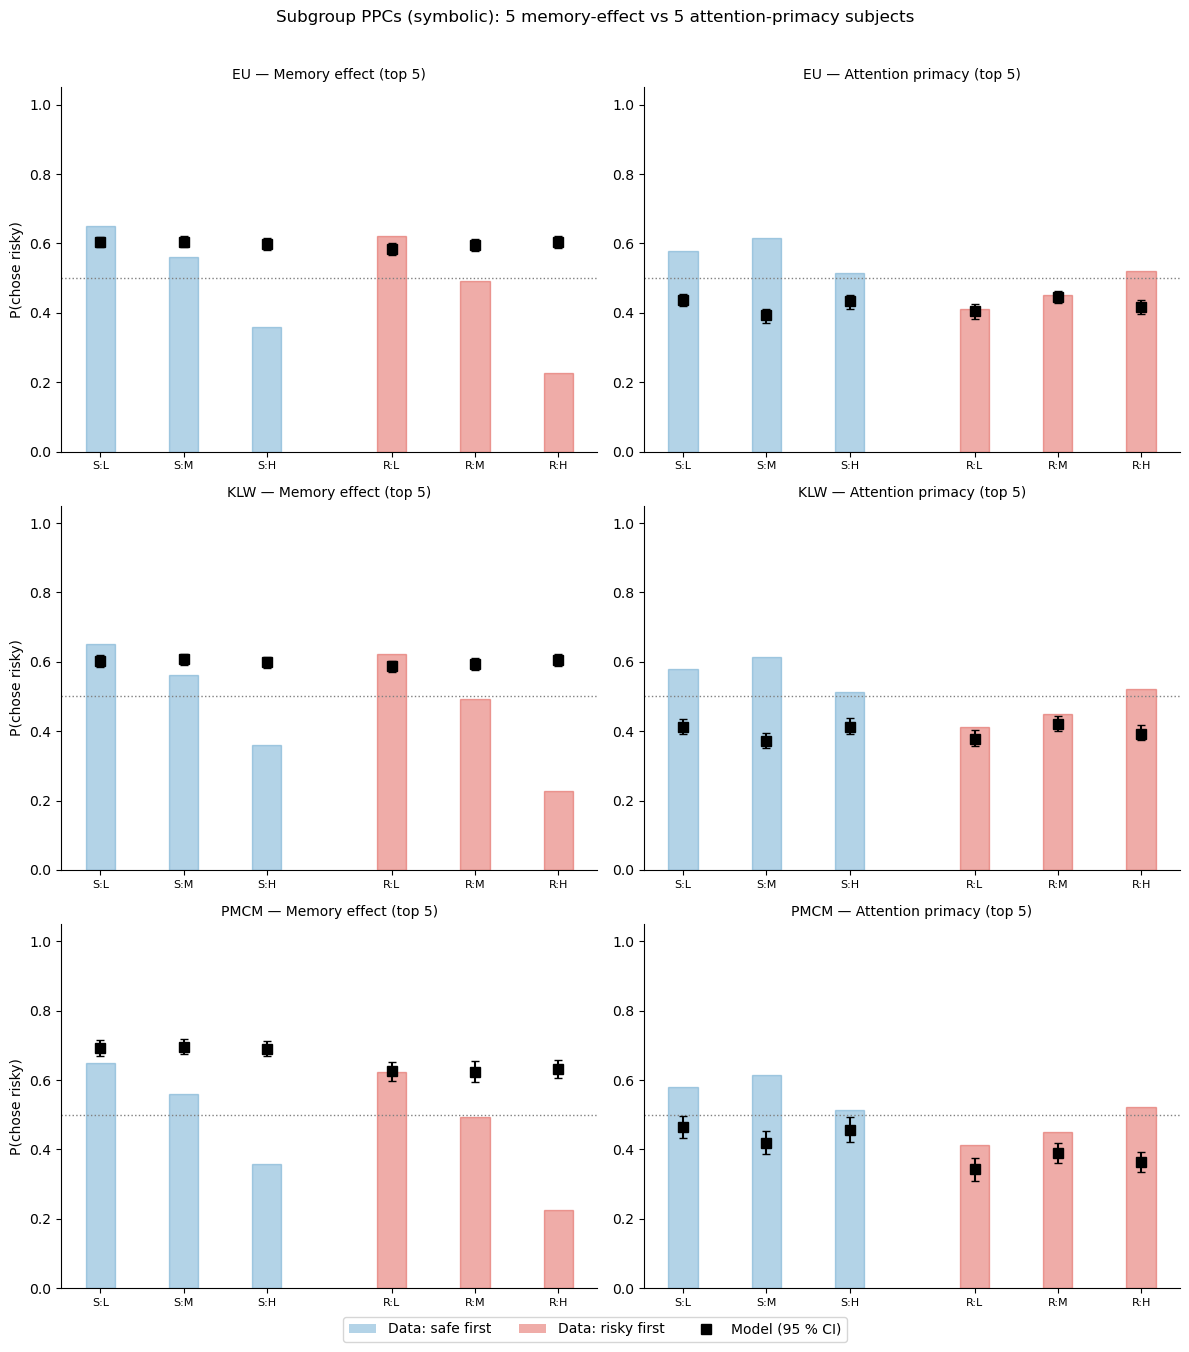

In [18]:
# Subject-group PPCs using model probability (p), not binary ll_bernoulli
# Average P(chose risky) over 5 extreme subjects per group

def subgroup_ppc(model, idata, df_raw, df_prepped, subject_ids, group_label):
    # Get model-predicted P(chose option 2) for all subjects
    ppc_df = model.ppc(df_raw, idata, var_names=['p'])
    ppc_p = ppc_df.xs('p', level='variable')
    sample_cols = ppc_p.columns.tolist()

    rows = []
    for subj in subject_ids:
        ppc_subj = ppc_p.xs(subj, level='subject').reset_index()
        obs_subj = df_raw.xs(subj, level='subject').reset_index()

        risky_first = ppc_subj['p1'] == 0.55
        # P(chose risky): flip when risky is option 1
        pred_risky = ppc_subj[sample_cols].values.copy()
        pred_risky[risky_first] = 1 - pred_risky[risky_first]

        obs_choice = obs_subj['choice'].values.astype(float)
        obs_risky = np.where(risky_first, 1 - obs_choice, obs_choice)

        order = np.where(risky_first, 'Risky first', 'Safe first')
        n_safe = np.where(risky_first, obs_subj['n2'], obs_subj['n1'])
        n_safe_bin = np.array(pd.qcut(n_safe, q=3, labels=['Low', 'Mid', 'High']))

        for trial_i in range(len(obs_subj)):
            rows.append({
                'subject': subj, 'order': order[trial_i],
                'n_safe_bin': str(n_safe_bin[trial_i]),
                'obs': obs_risky[trial_i],
                **{s: pred_risky[trial_i, j] for j, s in enumerate(sample_cols)},
            })
    
    df_all = pd.DataFrame(rows)
    # Average over subjects within group, then by order x stake
    grouped = df_all.groupby(['order', 'n_safe_bin'])
    obs_mean = grouped['obs'].mean()
    pred_vals = grouped[sample_cols].mean()  # mean over subjects+trials per sample
    pred_mean = pred_vals.mean(1)
    pred_lo   = pred_vals.quantile(0.025, axis=1)
    pred_hi   = pred_vals.quantile(0.975, axis=1)
    return obs_mean, pred_mean, pred_lo, pred_hi

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
groups = [
    ('Memory effect (top 5)', top5_memory),
    ('Attention primacy (top 5)', top5_attention),
]
model_list = [
    (model_eu_sym,   idata_eu_sym,   'EU'),
    (model_klw_sym,  idata_klw_sym,  'KLW'),
    (model_full_sym, idata_full_sym, 'PMCM'),
]
order_colors = {'Safe first': '#4393c3', 'Risky first': '#d73027'}

for col, (group_label, subj_ids) in enumerate(groups):
    for row, (model, idat, model_name) in enumerate(model_list):
        ax = axes[row, col]
        obs, pred, pred_lo, pred_hi = subgroup_ppc(
            model, idat, df_sym, df_sym_p, subj_ids, group_label)

        pos = 0
        x_pos, x_labels = [], []
        for order in ['Safe first', 'Risky first']:
            for stake in ['Low', 'Mid', 'High']:
                if (order, stake) not in obs.index:
                    continue
                x_pos.append(pos)
                x_labels.append(f'{order[0]}:{stake[0]}')
                c = order_colors[order]
                ax.bar(pos, obs.loc[(order, stake)], width=0.35,
                       color=c, alpha=0.4, edgecolor=c)
                ax.errorbar(pos, pred.loc[(order, stake)],
                           yerr=[[pred.loc[(order, stake)] - pred_lo.loc[(order, stake)]],
                                 [pred_hi.loc[(order, stake)] - pred.loc[(order, stake)]]],
                           fmt='s', ms=7, color='black', elinewidth=1.5, capsize=3, zorder=5)
                pos += 1
            pos += 0.5

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, ls=':', c='gray', lw=1)
        if col == 0: ax.set_ylabel('P(chose risky)')
        ax.set_title(f'{model_name} — {group_label}', fontsize=10)
        sns.despine(ax=ax)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#4393c3', alpha=0.4, label='Data: safe first'),
    Patch(facecolor='#d73027', alpha=0.4, label='Data: risky first'),
    Line2D([0], [0], marker='s', color='black', lw=0, ms=7, label='Model (95 % CI)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Subgroup PPCs (symbolic): 5 memory-effect vs 5 attention-primacy subjects',
             fontsize=12, y=1.01)
plt.tight_layout()

## ELPD model comparison

ELPD (via PSIS-LOO) formally ranks the three models.  Since we stored log-likelihoods
during sampling, `az.compare` works directly.

In [19]:
import arviz as az

print("=== Dot clouds ===")
compare_dot = az.compare({'EU': idata_eu, 'KLW': idata_klw, 'PMCM': idata_full})
print(compare_dot[['elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())

print("\n=== Symbolic ===")
compare_sym = az.compare({'EU': idata_eu_sym, 'KLW': idata_klw_sym, 'PMCM': idata_full_sym})
print(compare_sym[['elpd_loo', 'p_loo', 'elpd_diff', 'dse', 'warning']].to_string())

=== Dot clouds ===


         elpd_loo       p_loo   elpd_diff        dse  warning
PMCM -6042.782557  128.823215    0.000000   0.000000     True
KLW  -6791.725179   44.728476  748.942622  35.723550    False
EU   -6894.703778   58.247178  851.921221  37.140894     True

=== Symbolic ===


         elpd_loo       p_loo   elpd_diff        dse  warning
PMCM -5266.338131  249.393476    0.000000   0.000000     True
KLW  -5586.569619  121.725592  320.231488  26.070628     True
EU   -5682.690820  149.078932  416.352690  36.002629     True


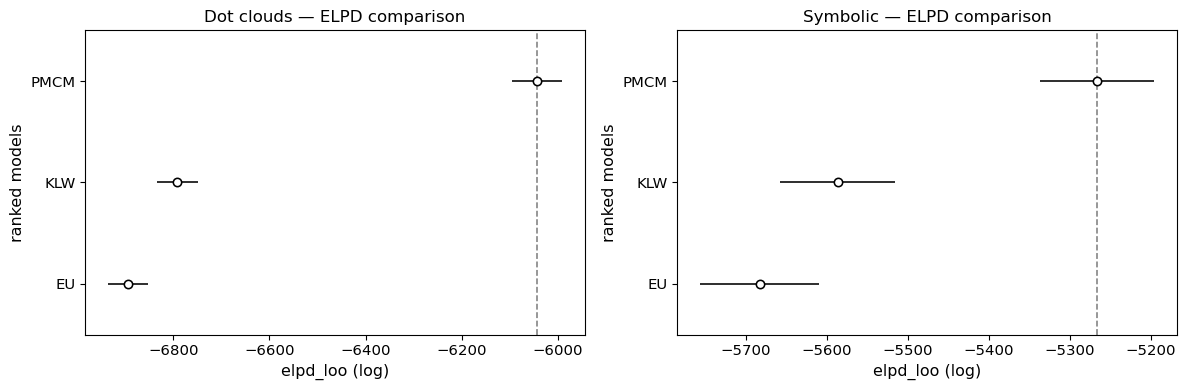

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
az.plot_compare(compare_dot, ax=axes[0])
axes[0].set_title('Dot clouds — ELPD comparison')
az.plot_compare(compare_sym, ax=axes[1])
axes[1].set_title('Symbolic — ELPD comparison')
plt.tight_layout()

## Summary

1. **Presentation order** creates asymmetric noise ($\nu_1 \neq \nu_2$), but the direction
   and magnitude of the asymmetry varies across participants.
2. For **dot clouds**: most participants show a memory effect ($\nu_1 > \nu_2$).  The PMCM
   captures the resulting order × stake-size interaction that EU and KLW cannot.
3. For **symbolic stimuli**: the pattern is more heterogeneous.  Some participants show
   memory effects, others show **attentional primacy** ($\nu_1 < \nu_2$) — as if they
   attend more to the first option when the encoding bottleneck is less severe.
4. **Individual PPCs** reveal whether the group-level fit hides poor individual fits —
   PMCM's separate $\nu_1, \nu_2$ can accommodate both strategies, while KLW and EU cannot.
5. **ELPD comparison** formally ranks the models: PMCM should dominate for dot clouds
   where the order effect is strong.

In [Lesson 4](lesson4.ipynb) we go one step further: instead of assuming a fixed
log-space noise, we let the noise curve $\nu(n)$ vary freely across magnitudes using
B-splines — and test whether Weber's law holds statistically via ELPD model comparison.